Entrenando el Random Forest... (esto puede tardar unos segundos)

--- INFORME DE RENDIMIENTO ---
              precision    recall  f1-score   support

           0       0.90      0.86      0.88      1008
           1       0.82      0.87      0.84       724

    accuracy                           0.86      1732
   macro avg       0.86      0.87      0.86      1732
weighted avg       0.87      0.86      0.87      1732



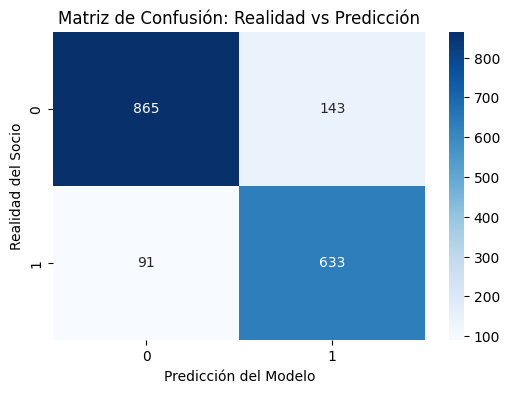

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Cargar la Tabla Analítica Base (ABT) actualizada
df = pd.read_csv("../../datos/procesados/abt_socios_modelo.csv")

# 2. PREPROCESAMIENTO FINAL
# Eliminamos columnas que causan "Data Leakage" o que ya han sido transformadas
columnas_a_eliminar = [
    'id_socio', 'fecha_nacimiento', 'fecha_alta', 
    'fecha_baja', 'tipo_cuota', 'codigo_postal'
]
df_ml = df.drop(columns=columnas_a_eliminar, errors='ignore')

# 3. CODIFICACIÓN (One-Hot Encoding)
# Convertimos textos ('sexo', 'tipo_socio') en columnas numéricas de 0 y 1
df_ml = pd.get_dummies(df_ml, columns=['sexo', 'tipo_socio'], drop_first=True)

# 4. DIVISIÓN DE DATOS (Train / Test Split)
X = df_ml.drop('es_baja', axis=1)
y = df_ml['es_baja']

# Dividimos: 80% para train, 20% para test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. ENTRENAMIENTO DEL MODELO
print("Entrenando el Random Forest... (esto puede tardar unos segundos)")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. EVALUACIÓN Y RESULTADOS
y_pred = model.predict(X_test)

print("\n--- INFORME DE RENDIMIENTO ---")
print(classification_report(y_test, y_pred))

# 7. MATRIZ DE CONFUSIÓN
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Realidad vs Predicción')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad del Socio')
plt.show()